## 1. Imports and Environment Setup

In [35]:
from pathlib import Path
from zipfile import ZipFile

import pandas as pd
import numpy as np

import emoji
import regex
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split

SEED = 37
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    
device = 'cuda' if torch.cuda.is_available() else 'cpu'

import warnings
warnings.filterwarnings(action='ignore', message='FutureWarning')

In [36]:
# # Download necessary NLTK corpora
# nltk.download('wordnet', quiet=True)
# print("NLTK resources checked and downloaded successfully!")

## 2. Data Loading and Cleaning

In [37]:
# import dataset
with ZipFile('spam_detection_dataset.zip') as z:
    with z.open(r'spam_email_dataset.csv') as f:
        df = pd.read_csv(f)
        
print('Read the data successfully')

Read the data successfully


In [38]:
df.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [39]:
# shape of dataset
print(f'Shape of dataset: {df.shape}')

Shape of dataset: (10000, 20)


In [40]:
# checking of null values
def null_check(dataset):
    null_count = df['email_text'].isnull().sum()
    
    if 50 > null_count > 0 :
        print(f'There are {null_count} null values\n\nDeleting null values...\n\nShape of dataset before droping null values: {df.shape}')
        df.dropna(inplace=True)
        print(f'Shape of dataset before droping null values: {df.shape}')
    elif null_count > 50:
        print(f'There are {null_count} null values. Need some supervision')
    else:
        print('No null values')
    

null_check(df)

No null values


In [41]:
# distribution of target feature
print('Distribution count of target feature')
print(df['label'].value_counts())

print('\nDistribution percentage of target feature')
print(df['label'].value_counts()/df.shape[0] * 100)

Distribution count of target feature
label
0    6005
1    3995
Name: count, dtype: int64

Distribution percentage of target feature
label
0    60.05
1    39.95
Name: count, dtype: float64


In [42]:
# mapper
label2id = {'ham': 0, 'spam': 1}
id2label = {0: 'ham', 1: 'spam'}

In [43]:
tokenizer = RegexpTokenizer(r"\d+\.\d+|\w+|[^\w\s]")
lammetizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        print('Not string type')
        return []

    # change to lowercase
    text = text.lower()
    
    # replace all urls with urltoken
    text = regex.sub(r'https?://\S+|www.S+', '<url>', text)
    # replace all the usernames mention with usertoken
    text = regex.sub(r'@\w+', '<user>', text)
    # replace all emoji with emojitoken
    text = emoji.replace_emoji(text, replace='<emoji>')
    
    # tokenize
    tokens = tokenizer.tokenize(text)
    
    # lemmaitize
    clean_tokens = [lammetizer.lemmatize(token) for token in tokens if len(token)>1 and not token.isdigit()]
    
    return clean_tokens

In [44]:
print(preprocess_text("Hello this is @PrashantKumar! I'm 😊. This is a good website https://sxioalsajie.sidoa. 👋🏼"))

['hello', 'this', 'is', 'user', 'emoji', 'this', 'is', 'good', 'website', 'url', 'emoji']


## Build Vocabulary

In [45]:
class Vocabulary:
    def __init__(self, min_frequency: int):
        self.min_freq = min_frequency
        self.stoi = {'<pad>': 0, '<unk>': 1, '<url>': 2, '<user>': 3, '<emoji>': 4}
        self.itos = {0: '<pad>', 1: '<unk>', 2: '<url>', 3: '<user>', 4: '<emoji>'}
        self.freq = {}

    def build_voacb(self, tokenized_text: pd.Series):
        for tokens in tokenized_text:
            for token in tokens:
                self.freq[token] = self.freq.get(token, 0) + 1

        idx = 5
        for token, count in self.freq.items():
            if count > self.min_freq:
                self.stoi[token] = idx
                self.itos[idx] = token
                idx+=1

    def tokenToNums(self, tokens: list):
        return [self.stoi.get(token, 1) for token in tokens]

    def __len__(self):
        return len(self.stoi)

In [46]:
print('Preprocessing text...')
df['clean_tokens'] = df['email_text'].apply(preprocess_text)
print('Preprocess completed..')
print(f'\nEmail Text: {df['email_text'].iloc[-1]}\nCleaned Tokens: {df['clean_tokens'].iloc[-1]}')

Preprocessing text...


Preprocess completed..

Email Text: budget review - Day measure few alone decade account get she. Some left church source.
Cleaned Tokens: ['budget', 'review', 'day', 'measure', 'few', 'alone', 'decade', 'account', 'get', 'she', 'some', 'left', 'church', 'source']


In [47]:
df[['email_text', 'clean_tokens']].head()

,email_text,clean_tokens
0,budget review - Statement our I claim world st...,"[budget, review, statement, our, claim, world,..."
1,team sync - President series today already. In...,"[team, sync, president, series, today, already..."
2,win free urgent offer limited limited urgent u...,"[win, free, urgent, offer, limited, limited, u..."
3,guarantee click now cash offer click now guara...,"[guarantee, click, now, cash, offer, click, no..."
4,team sync - Significant property hotel not add...,"[team, sync, significant, property, hotel, not..."


In [48]:
vocab = Vocabulary(min_frequency=4)
vocab.build_voacb(df['clean_tokens'])
print(f'Successfully created vocabulary\nLenght of vocabulary: {len(vocab)}')

Successfully created vocabulary
Lenght of vocabulary: 981


## Custom Dataset Class

In [49]:
class createDataset(Dataset):
    def __init__(self, tokenized_texts, labels, vocab, max_len=50):
        self.tokenized_texts = tokenized_texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
    
    def __getitem__(self, index):
        tokens = self.tokenized_texts[index]
        numericalized_tokens = self.vocab.tokenToNums(tokens)
        
        # pad and turncate
        if len(numericalized_tokens) > self.max_len:
            numericalized_tokens = numericalized_tokens[:self.max_len]
        else:
            numericalized_tokens = numericalized_tokens + [0] * (self.max_len - len(numericalized_tokens)) # directly 0 instead of self.vocab.stoi['pad']
            
        return torch.tensor(numericalized_tokens, dtype=torch.long), torch.tensor(self.labels[index], dtype=torch.long)

    def __len__(self):
        return len(self.tokenized_texts)
    

In [50]:
MAX_LEN = 40
BATCH_SIZE = 60

cols = df.columns.tolist()
cols.remove('label')
target = 'label'

X_train, X_test, Y_train, Y_test  = train_test_split(df[cols], df[target], train_size=0.85, shuffle=True)

In [51]:
train_dataset = createDataset(X_train['clean_tokens'].tolist(), Y_train.tolist(), vocab=vocab, max_len=MAX_LEN)
test_dataset = createDataset(X_test['clean_tokens'].tolist(), Y_test.tolist(), vocab=vocab, max_len=MAX_LEN)

print('Successfully created Datasets')

Successfully created Datasets


In [52]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print('Successfully created DataLoader')

Successfully created DataLoader


In [53]:
# check dataset & dataloader proper working
for idx, (X, Y) in enumerate(train_loader):
    if idx == 3: break
    print(f'Numericalized_Tokens: {X}\nLabel: {Y}\n')

Numericalized_Tokens: tensor([[ 53,  54,  53,  ...,   0,   0,   0],
        [ 77,  78, 822,  ...,   0,   0,   0],
        [ 53,  54,  41,  ...,   0,   0,   0],
        ...,
        [375, 101, 316,  ...,   0,   0,   0],
        [ 47, 938, 290,  ...,   0,   0,   0],
        [ 38,  55,  53,  ...,   0,   0,   0]])
Label: tensor([1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
        1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
        1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1])

Numericalized_Tokens: tensor([[ 77,  78, 304,  ...,   0,   0,   0],
        [ 77,  78,  58,  ...,   0,   0,   0],
        [ 40,  55,  52,  ...,   0,   0,   0],
        ...,
        [ 38,  53,  54,  ...,   0,   0,   0],
        [ 42,  39,  42,  ...,   0,   0,   0],
        [375, 645, 190,  ...,   0,   0,   0]])
Label: tensor([0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
        0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,

## LSTM Model

In [54]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, output_dim, embed_dim, hidden_dim, num_layers=2, dropout=0.3):
        #super(LSTMModel, self).__init__()
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.model = nn.LSTM(input_size=embed_dim,
                        hidden_size=hidden_dim,
                        num_layers=num_layers,
                        batch_first=True,
                        bias=True, 
                        bidirectional=True,
                        dropout=dropout if num_layers > 1 else 0
                        )
        self.fc = nn.Linear(hidden_dim*2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tensor_token_id):
        embedded = self.dropout(self.embedding(tensor_token_id))
        lstm_out, (hidden, cell) = self.model(embedded)
        hidden_last = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        
        logits = self.fc(self.dropout(hidden_last))
        return logits

In [55]:
OUTPUT_DIM = 2
EMBED_DIM = 182
HIDDEN_DIM = 128
NUM_LAYERS = 3
DROPUT = 0.3

In [56]:
lstmModel = LSTMModel(vocab_size=len(vocab),
                      output_dim=OUTPUT_DIM,
                      embed_dim=EMBED_DIM,
                      hidden_dim=HIDDEN_DIM,
                      num_layers=NUM_LAYERS,
                      dropout=DROPUT)
lstmModel.to(device)
print(lstmModel)

LSTMModel(
  (embedding): Embedding(981, 182, padding_idx=0)
  (model): LSTM(182, 128, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=256, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


## Model Training

In [ ]:
LEARNING_RATE = 1e-4
EPOCHS = 2

In [67]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(lstmModel.parameters(),lr=LEARNING_RATE)

In [68]:
def train_model(train_dataloader, model, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for x_batch, y_batch in train_dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        
        logits = model(x_batch)

        loss = criterion(logits, y_batch)
        loss.backward()

        
        optimizer.step()

        total+= len(y_batch)
        total_loss += loss.item() * len(y_batch)
        
        pred = torch.argmax(logits, dim=1)
        correct += (pred == y_batch).sum().item()

    return total_loss/total, correct/total

In [69]:
def eval_model(test_dataloader, model, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            logits = model(x_batch)
            
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            
            pred = torch.argmax(logits, dim=1)
            correct += (pred == y_batch).sum().item()
            
            total+=len(y_batch)
            
    return total_loss/total, correct/total

In [70]:
for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_model(train_dataloader=train_loader,
                                        model=lstmModel,
                                        criterion=criterion,
                                        optimizer=optimizer,
                                        device=device)
    test_loss, test_acc = eval_model(test_dataloader=train_loader,
                                     model=lstmModel,
                                     criterion=criterion,
                                     device=device)
    
    print(f'Epoch [{epoch}/{EPOCHS}] | Train Loss: {train_loss:.3f} | Train Accuracy: {train_acc*100:.3f}% | Test Loss: {test_loss:.3f} | Test Accuracy: {test_acc*100:.3f}%')

Epoch [1/2] | Train Loss: 0.000 | Train Accuracy: 100.000% | Test Loss: 0.000 | Test Accuracy: 100.000%
Epoch [2/2] | Train Loss: 0.000 | Train Accuracy: 100.000% | Test Loss: 0.000 | Test Accuracy: 100.000%


## Model Evaluation & Confusion Matrix

In [75]:
lstmModel.eval()
all_preds = []
all_labels = []

In [76]:
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits = lstmModel(x_batch)
        loss = criterion(logits, y_batch)
        
        preds = torch.argmax(logits, dim=1).cpu().numpy()
    
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

In [83]:
target_names = ['spam', 'ham']

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

In [85]:
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

        spam       1.00      1.00      1.00      5086
         ham       1.00      1.00      1.00      3414

    accuracy                           1.00      8500
   macro avg       1.00      1.00      1.00      8500
weighted avg       1.00      1.00      1.00      8500



Text(0.5, 1.0, 'Sentiment Analysis Evaluation Confusion Matrix')

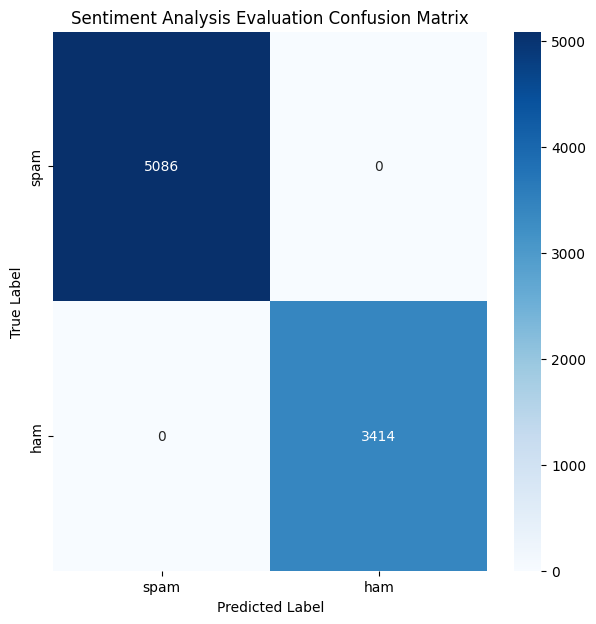

In [86]:
# confusion matrix visual
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Sentiment Analysis Evaluation Confusion Matrix')

# Test Model with custom Inputs

In [97]:
emails = [
        'Hey bro. This is Gaya have you ever wonder to come to Thailand. You will definitely have a good time here. Click here https://iej0w9u.=idjajei and book you seat now.',
        'Win 10000 dollors just one click and you will be a billioneir. You can do it. One way or another. Just click here you have it all https://wioda90394kjdas. 10000 dollors are waiting. Dont miss the chance',
        "Enjoy 50% off on your first flight booking with makemytrip using coupon 'FIRST'",
        "Congratulations Sir you have won a Jackpot of RS. 2,000,000 please share your OTP to claim your winnings.",
        "Respected Sir, please share the details regarding project submission deadlines"]

In [98]:
labeltoName = {1: 'spam', 0: 'ham'}

In [99]:
def test_model(model, input, vocab, max_len=40):
    model.eval()
    clean_tokens = preprocess_text(input)
    numericalized = vocab.tokenToNums(clean_tokens)
    if len(numericalized) > max_len:
        numericalized = numericalized[:max_len]
    else: numericalized = numericalized + [0] * (max_len - len(numericalized))
    
    input_tensor = torch.tensor([numericalized], dtype=torch.long).to(device)
    
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred_label = int(torch.argmax(logits, dim=1).item())

    return labeltoName[pred_label]

In [100]:
for email in emails:
    print(f'Email: {email}')
    print(f'The email is a {test_model(lstmModel, rf'{email}', vocab, max_len=40)}\n')

Email: Hey bro. This is Gaya have you ever wonder to come to Thailand. You will definitely have a good time here. Click here https://iej0w9u.=idjajei and book you seat now.
The email is a ham

Email: Win 10000 dollors just one click and you will be a billioneir. You can do it. One way or another. Just click here you have it all https://wioda90394kjdas. 10000 dollors are waiting. Dont miss the chance
The email is a spam

Email: Enjoy 50% off on your first flight booking with makemytrip using coupon 'FIRST'
The email is a ham

Email: Congratulations Sir you have won a Jackpot of RS. 2,000,000 please share your OTP to claim your winnings.
The email is a ham

Email: Respected Sir, please share the details regarding project submission deadlines
The email is a ham

